# Customer Segmentation in Banking using K-Means Clustering

## Problem Statement

We are given banking customer data with:

- Income
- Number of transactions
- Credit score
- Account type

## Tasks

1. Handle missing values
2. Encode categorical variable `account_type`
3. Normalize / scale the data
4. Apply K-Means clustering
5. Choose optimal K
6. Interpret clusters

## Expected Business Interpretation

Identify:

- High-value customers
- Moderate customers
- Risky / low-credit customers


## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

# To display all columns
pd.set_option('display.max_columns', None)


## Step 2: Load the Dataset

The dataset file used here is `bfsi.csv`.


In [4]:
# Load dataset
file_path = "bfsi.csv"

df = pd.read_csv(file_path)

# Display first few rows
df.head()


,income,transactions,credit_score,account_type
0,14687.426645,35.0,627.443037,Standard
1,26228.229229,41.0,670.311334,Standard
2,16750.307944,52.0,683.352805,Standard
3,21332.145102,63.0,545.499113,Gold
4,44419.721408,62.0,NaN,Standard


## Step 3: Understand the Dataset

In [5]:
# Shape of dataset
print("Rows and Columns:", df.shape)

# Dataset information
df.info()


Rows and Columns: (205, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   income        195 non-null    float64
 1   transactions  195 non-null    float64
 2   credit_score  195 non-null    float64
 3   account_type  195 non-null    object 
dtypes: float64(3), object(1)
memory usage: 6.5+ KB


In [6]:
# Summary statistics
df.describe(include='all')


,income,transactions,credit_score,account_type
count,1.950000e+02,195.000000,195.000000,195
unique,NaN,NaN,NaN,4
top,NaN,NaN,NaN,Gold
freq,NaN,NaN,NaN,81
mean,1.056500e+05,89.400000,663.570967,NaN
std,4.299484e+05,61.802012,87.423524,NaN
min,6.448652e+03,6.000000,358.133161,NaN
25%,2.733896e+04,42.000000,615.462771,NaN
50%,3.904912e+04,81.000000,674.634324,NaN
75%,5.581268e+04,117.000000,729.741776,NaN


## Step 4: Check Missing Values

Missing values must be handled before applying K-Means clustering.


In [7]:
df.isnull().sum()


income          10
transactions    10
credit_score    10
account_type    10
dtype: int64

## Step 5: Handle Missing Values

### Numerical Columns
For numerical columns, we use **median** because it is less affected by outliers.

### Categorical Column
For categorical columns, we use **mode**, which means the most frequent value.


In [8]:
# Identify expected columns
num_cols = ['income', 'transactions', 'credit_score']
cat_col = 'account_type'

# Handle missing values in numerical columns
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Handle missing values in categorical column
if cat_col in df.columns:
    df[cat_col] = df[cat_col].fillna(df[cat_col].mode()[0])

# Verify missing values again
df.isnull().sum()


income          0
transactions    0
credit_score    0
account_type    0
dtype: int64

## Step 6: Encode Categorical Variable

K-Means works only with numerical values.

So, we convert `account_type` into numbers using Label Encoding.


In [9]:
encoder = LabelEncoder()

df['account_type_encoded'] = encoder.fit_transform(df['account_type'])

# Show encoding mapping
encoding_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
encoding_mapping


{'Basic': np.int64(0),
 'Gold': np.int64(1),
 'Premium': np.int64(2),
 'Standard': np.int64(3)}

In [10]:
df[['account_type', 'account_type_encoded']].head()


,account_type,account_type_encoded
0,Standard,3
1,Standard,3
2,Standard,3
3,Gold,1
4,Standard,3


## Step 7: Select Features for Clustering

We use:

- income
- transactions
- credit_score
- account_type_encoded


In [11]:
features = ['income', 'transactions', 'credit_score', 'account_type_encoded']

X = df[features]

X.head()


,income,transactions,credit_score,account_type_encoded
0,14687.426645,35.0,627.443037,3
1,26228.229229,41.0,670.311334,3
2,16750.307944,52.0,683.352805,3
3,21332.145102,63.0,545.499113,1
4,44419.721408,62.0,674.634324,3


## Step 8: Normalize / Scale the Data

K-Means uses distance calculation.

If we do not scale, large-value features like `income` can dominate smaller-value features like `transactions`.

`StandardScaler` converts values into a common scale with:

- Mean = 0
- Standard deviation = 1


In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert scaled data into DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()


,income,transactions,credit_score,account_type_encoded
0,-0.209591,-0.897619,-0.430983,1.351859
1,-0.182014,-0.797866,0.072882,1.351859
2,-0.204661,-0.614984,0.226168,1.351859
3,-0.193713,-0.432103,-1.394133,-0.572663
4,-0.138546,-0.448729,0.123693,1.351859


## Step 9: Choose Optimal K using Elbow Method

The Elbow Method helps identify the best number of clusters.

### Inertia / WCSS
Inertia measures how close data points are to their cluster centroid.

Lower inertia means tighter clusters.

But if K keeps increasing, inertia will always reduce.  
So we look for the point where the reduction becomes slow. That point is called the **elbow point**.


In [15]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Display inertia values
elbow_df = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertia
})

elbow_df


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

,K,Inertia
0,1,820.000000
1,2,580.270092
2,3,395.702090
3,4,243.183308
4,5,197.462735
5,6,167.228418
6,7,139.987622
7,8,123.051688
8,9,105.451120
9,10,94.171838


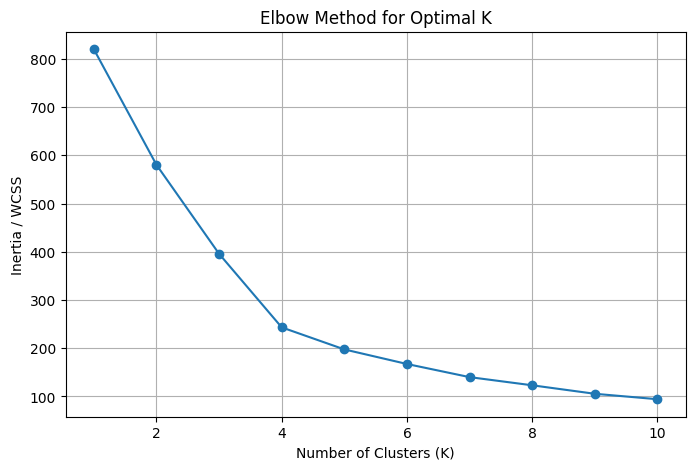

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia / WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()


## Step 10: Apply K-Means Clustering

For business segmentation, we commonly start with **K = 3**:

1. Premium customers
2. Moderate customers
3. Risky / low-credit customers

You can change `optimal_k` based on your elbow graph.


In [16]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,income,transactions,credit_score,account_type,account_type_encoded,Cluster
0,14687.426645,35.0,627.443037,Standard,3,0
1,26228.229229,41.0,670.311334,Standard,3,0
2,16750.307944,52.0,683.352805,Standard,3,0
3,21332.145102,63.0,545.499113,Gold,1,1
4,44419.721408,62.0,674.634324,Standard,3,0


## Step 11: Cluster Summary

Now we calculate the average income, transactions, and credit score for each cluster.


In [17]:
cluster_summary = df.groupby('Cluster')[['income', 'transactions', 'credit_score']].mean()

cluster_summary


,income,transactions,credit_score
Cluster,,,
0,5.714729e+04,104.649635,706.202812
1,3.179112e+04,40.250000,575.519103
2,2.782107e+06,332.500000,639.918532


In [18]:
# Count of customers in each cluster
df['Cluster'].value_counts().sort_index()


Cluster
0    137
1     64
2      4
Name: count, dtype: int64

## Step 12: Visualize Clusters

Here we visualize customers using:

- Income
- Credit Score

Each color represents one cluster.


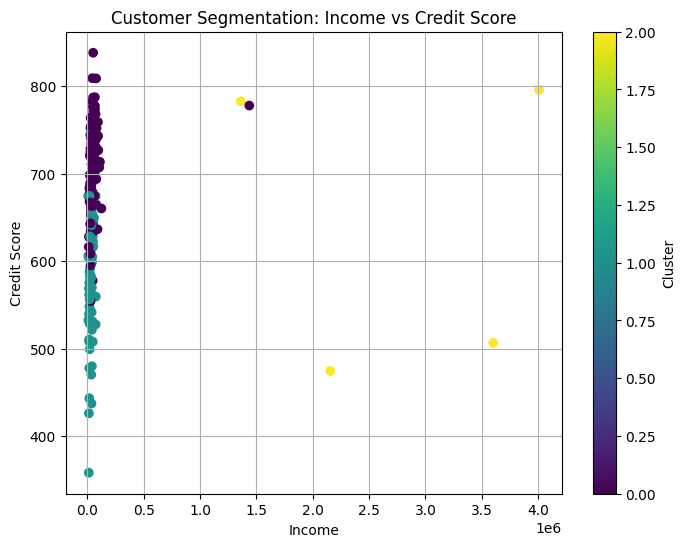

In [19]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df['income'],
    df['credit_score'],
    c=df['Cluster']
)

plt.xlabel('Income')
plt.ylabel('Credit Score')
plt.title('Customer Segmentation: Income vs Credit Score')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()


## Step 13: Interpret Clusters Automatically

We classify clusters based on average values.

General logic:

- Highest income + high credit score → Premium customers
- Medium income + medium credit score → Moderate customers
- Low credit score → Risky / low-credit customers


In [25]:
cluster_profile = cluster_summary.copy()

# Rank clusters
premium_cluster = cluster_profile.sort_values(
    by=['income', 'credit_score', 'transactions'],
    ascending=False
).index[0]

risky_cluster = cluster_profile.sort_values(
    by=['credit_score', 'income'],
    ascending=True
).index[0]

moderate_cluster = [c for c in cluster_profile.index if c not in [premium_cluster, risky_cluster]]

print("Premium Customer Cluster:", premium_cluster)
print("Risky / Low-Credit Customer Cluster:", risky_cluster)
print("Moderate Customer Cluster(s):", moderate_cluster)


Premium Customer Cluster: 2
Risky / Low-Credit Customer Cluster: 1
Moderate Customer Cluster(s): [0]


## Business Interpretation

### Premium Customers
Customers in this cluster usually have:

- High income
- High number of transactions
- Good credit score

Possible business actions:

- Offer premium banking services
- Wealth management products
- Investment plans
- Premium credit cards

### Moderate Customers
Customers in this cluster usually have:

- Medium income
- Average transactions
- Stable credit score

Possible business actions:

- Cross-sell savings products
- Offer personal loans
- Recommend insurance products

### Risky / Low-Credit Customers
Customers in this cluster usually have:

- Low credit score
- Lower income or unstable transaction behavior

Possible business actions:

- Monitor credit exposure
- Offer financial education
- Apply risk-based loan approval


## Question 1: Which cluster represents premium customers?

The premium customer cluster is the one with:

- Highest average income
- High transaction count
- High credit score


In [26]:
print("Premium customer cluster is:", premium_cluster)

df[df['Cluster'] == premium_cluster].head()


Premium customer cluster is: 2


,income,transactions,credit_score,account_type,account_type_encoded,Cluster
200,4.009711e+06,301.0,795.756607,Basic,0,2
201,1.361927e+06,331.0,782.840137,Basic,0,2
202,2.154742e+06,301.0,474.457644,Premium,2,2
204,3.602047e+06,397.0,506.619739,Premium,2,2


## Question 2: Are there customers with high income but low credit score?

We can identify such customers by checking:

- Income above 75th percentile
- Credit score below 25th percentile


In [27]:
high_income_threshold = df['income'].quantile(0.75)
low_credit_threshold = df['credit_score'].quantile(0.25)

high_income_low_credit = df[
    (df['income'] >= high_income_threshold) &
    (df['credit_score'] <= low_credit_threshold)
]

print("High income threshold:", high_income_threshold)
print("Low credit score threshold:", low_credit_threshold)
print("Number of high-income but low-credit customers:", len(high_income_low_credit))

high_income_low_credit


High income threshold: 54702.72975745961
Low credit score threshold: 616.7886278347788
Number of high-income but low-credit customers: 4


,income,transactions,credit_score,account_type,account_type_encoded,Cluster
46,7.219779e+04,34.0,527.706504,Standard,3,1
121,7.398146e+04,36.0,559.493434,Standard,3,1
202,2.154742e+06,301.0,474.457644,Premium,2,2
204,3.602047e+06,397.0,506.619739,Premium,2,2


### Business Meaning

Customers with high income but low credit score are important.

They may:

- Earn well but have poor repayment history
- Have high debt exposure
- Be risky for loans despite high income

So banks should not depend only on income.


## Question 3: How do outliers affect clustering?

K-Means is sensitive to outliers because it uses distance from centroids.

Outliers can:

- Pull centroids away from real customer groups
- Create misleading clusters
- Make premium customers look more spread out
- Reduce clustering quality

### Common Solutions

- Remove extreme outliers using IQR or Z-score
- Use RobustScaler instead of StandardScaler
- Try DBSCAN for noisy data
- Cap extreme values using winsorization


In [28]:
# Simple outlier detection using IQR for income
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

income_outliers = df[
    (df['income'] < lower_bound) |
    (df['income'] > upper_bound)
]

print("Number of income outliers:", len(income_outliers))

income_outliers


Number of income outliers: 9


,income,transactions,credit_score,account_type,account_type_encoded,Cluster
20,1.105889e+05,90.0,713.556911,Gold,1,0
57,1.043685e+05,121.0,707.205633,Premium,2,0
93,9.615953e+04,167.0,726.778712,Premium,2,0
138,1.235546e+05,33.0,660.191136,Standard,3,0
200,4.009711e+06,301.0,795.756607,Basic,0,2
201,1.361927e+06,331.0,782.840137,Basic,0,2
202,2.154742e+06,301.0,474.457644,Premium,2,2
203,1.436439e+06,218.0,777.895344,Premium,2,0
204,3.602047e+06,397.0,506.619739,Premium,2,2


## Final Conclusion

K-Means clustering helps banks segment customers into useful business groups.

This segmentation can support:

- Personalized offers
- Premium customer targeting
- Risk-based lending
- Customer retention
- Fraud and credit risk monitoring

In this problem, the most useful cluster interpretation is:

- Premium customers → High income, high transactions, high credit score
- Moderate customers → Average financial behavior
- Risky customers → Low credit score or unstable financial behavior
